# AuraFitness Rule Engine Testing

This notebook tests the first rule-based AI engine using the cleaned real exercise dataset.

Engine:

- Exercise recommendation engine

Input:

- `ai/datasets/processed/exercises_clean.csv`

Rules:

- Use real cleaned exercise data only
- Do not use fake training data
- Do not train ML models yet
- Difficulty is estimated only for ranking, not added to the source dataset

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.recommendation_engine import RecommendationRequest, recommend_exercises, load_clean_exercises

FIGURES_DIR = AI_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Load cleaned real exercise dataset

This cell loads the validated real cleaned dataset.

In [2]:
exercises_df = load_clean_exercises()

print("Shape:", exercises_df.shape)
display(exercises_df.head())

Shape: (1730, 10)


,exercise_id,name,body_part,target_muscle,secondary_muscles,equipment,exercise_type,difficulty_level,instructions,source_dataset
0,ex_0e2eff7dc4,3/4 sit-up,abdominals,abdominals,unknown,bodyweight,strength,unknown,unknown,gym_exercises
1,ex_a66a59d23a,Ab Roller,abdominals,abdominals,unknown,other,strength,unknown,unknown,gym_exercises
2,ex_b1ced5f64e,Ab bicycle,abdominals,abdominals,unknown,bodyweight,strength,unknown,unknown,gym_exercises
3,ex_32a5b22d7e,Barbell Ab Rollout - On Knees,abdominals,abdominals,unknown,barbell,strength,unknown,unknown,gym_exercises
4,ex_3f76f9aa3b,Barbell roll-out,abdominals,abdominals,unknown,barbell,strength,unknown,unknown,gym_exercises


## Test recommendation requests

These requests test realistic user needs such as chest training, back training, fat loss, and muscle gain.

In [3]:
requests = [
    RecommendationRequest(
        body_part="chest",
        target_muscle="pectorals",
        equipment="dumbbell",
        exercise_type="strength",
        fitness_level="beginner",
        goal="muscle_gain",
        limit=8,
    ),
    RecommendationRequest(
        body_part="back",
        target_muscle="lats",
        equipment="cable",
        exercise_type="strength",
        fitness_level="beginner",
        goal="strength",
        limit=8,
    ),
    RecommendationRequest(
        body_part="upper legs",
        target_muscle="quads",
        equipment="bodyweight",
        exercise_type="strength",
        fitness_level="beginner",
        goal="fat_loss",
        limit=8,
    ),
]

all_results = []

for index, request in enumerate(requests, start=1):
    result_df = recommend_exercises(request, exercises_df)
    result_df["test_case"] = f"case_{index}"
    all_results.append(result_df)

    print(f"\nTest case {index}")
    display(result_df[[
        "name",
        "body_part",
        "target_muscle",
        "equipment",
        "estimated_difficulty",
        "score",
        "recommendation_reason",
    ]])

combined_results_df = pd.concat(all_results, ignore_index=True)


Test case 1


,name,body_part,target_muscle,equipment,estimated_difficulty,score,recommendation_reason
0,dumbbell incline alternate press,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
1,dumbbell incline bench press,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
2,dumbbell incline fly,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
3,dumbbell incline fly on exercise ball,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
4,dumbbell incline hammer press,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
5,dumbbell incline palm-in press,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
6,dumbbell incline press on exercise ball,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."
7,dumbbell incline twisted flyes,chest,pectorals,dumbbell,beginner,136,"Recommended because it targets pectorals, matc..."



Test case 2


,name,body_part,target_muscle,equipment,estimated_difficulty,score,recommendation_reason
0,alternate lateral pulldown,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
1,cable bar lateral pulldown,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
2,cable cross-over lateral pulldown,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
3,cable incline pushdown,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
4,cable lat pulldown full range of motion,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
5,cable lateral pulldown with v-bar,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
6,cable pulldown,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."
7,cable pushdown (straight arm) v. 2,back,lats,cable,beginner,130,"Recommended because it targets lats, matches b..."



Test case 3


,name,body_part,target_muscle,equipment,estimated_difficulty,score,recommendation_reason
0,backward jump,upper legs,quads,bodyweight,beginner,134,"Recommended because it targets quads, matches ..."
1,balance board,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
2,quads,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
3,quick feet v. 2,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
4,sissy squat,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
5,split squats,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
6,squat to overhead reach,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."
7,squat to overhead reach with twist,upper legs,quads,bodyweight,beginner,128,"Recommended because it targets quads, matches ..."


## Chart recommendation scores

This chart shows the score distribution for recommendation outputs.

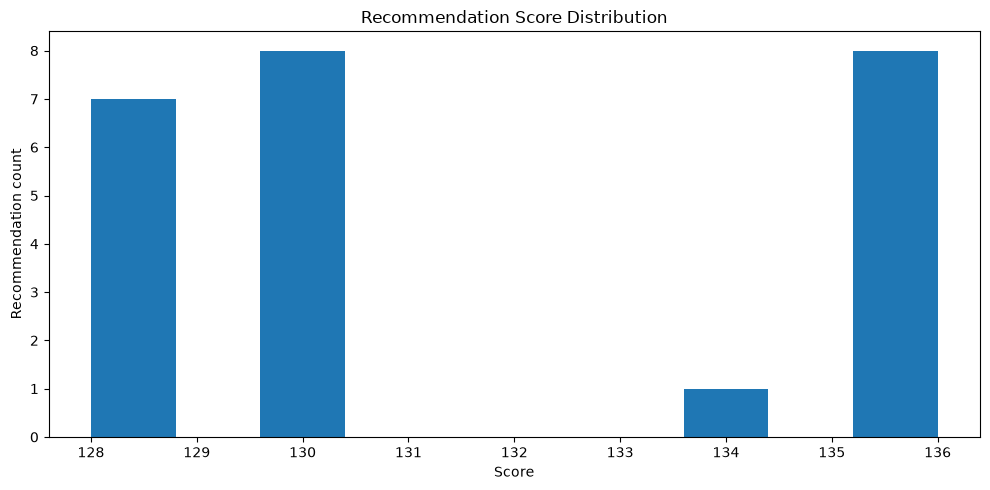

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\rule_engine_recommendation_score_distribution.png


In [4]:
plt.figure(figsize=(10, 5))
plt.hist(combined_results_df["score"], bins=10)
plt.title("Recommendation Score Distribution")
plt.xlabel("Score")
plt.ylabel("Recommendation count")
plt.tight_layout()

output_path = FIGURES_DIR / "rule_engine_recommendation_score_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart recommended equipment types

This chart shows what equipment appears in the recommendation results.

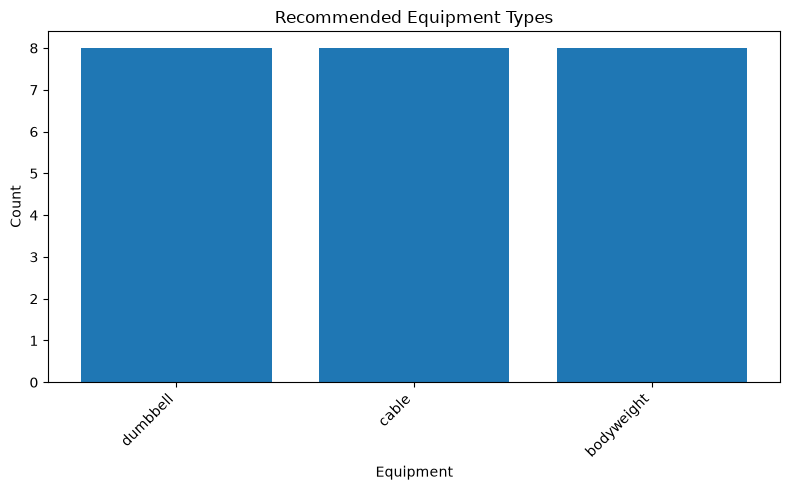

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\rule_engine_recommended_equipment.png


In [5]:
equipment_counts = combined_results_df["equipment"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(equipment_counts.index, equipment_counts.values)
plt.title("Recommended Equipment Types")
plt.xlabel("Equipment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "rule_engine_recommended_equipment.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save recommendation test results

This saves the rule engine test results for review.

In [6]:
output_file = AI_ROOT / "reports" / "rule_engine_test_results.csv"
combined_results_df.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\rule_engine_test_results.csv


## Quality filter review

This section checks that known source-data quality issues are excluded from recommendation results.

The original real dataset is not deleted or rewritten. The recommendation engine only filters blocked records from user-facing outputs.

In [7]:
quality_request = RecommendationRequest(
    body_part="chest",
    target_muscle="pectorals",
    equipment="dumbbell",
    exercise_type="strength",
    fitness_level="beginner",
    goal="muscle_gain",
    limit=30,
)

quality_results_df = recommend_exercises(quality_request, exercises_df)

display(quality_results_df[[
    "name",
    "body_part",
    "target_muscle",
    "equipment",
    "score",
    "recommendation_reason",
]])

blocked_keyword = "breeding"

blocked_rows = quality_results_df[
    quality_results_df["name"].astype(str).str.lower().str.contains(blocked_keyword, na=False)
]

if not blocked_rows.empty:
    raise ValueError("Blocked suspicious exercise still appears in recommendations.")

print("Quality filter check passed. No blocked suspicious exercise appears.")

,name,body_part,target_muscle,equipment,score,recommendation_reason
0,dumbbell incline alternate press,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
1,dumbbell incline bench press,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
2,dumbbell incline fly,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
3,dumbbell incline fly on exercise ball,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
4,dumbbell incline hammer press,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
5,dumbbell incline palm-in press,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
6,dumbbell incline press on exercise ball,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
7,dumbbell incline twisted flyes,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
8,dumbbell lying hammer press,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."
9,dumbbell lying pullover on exercise ball,chest,pectorals,dumbbell,136,"Recommended because it targets pectorals, matc..."


Quality filter check passed. No blocked suspicious exercise appears.
